In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import numpy as np

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data


# Model results (10 June 2026)
## Model fitting and pre-processing

Before running the analyses in this notebook, three steps (model fitting, simulation, and aggregation of model fitting results) need to be performed. Since fitting all models to all particpants can take a few days (depending on your computer), these steps have been performed and the results have been saved to the `results/` directory. 

If you want to replicate the full model fitting pipeline, you will need to run the following three steps. 

If you are interested in generating the main model figures starting from pre-processed model results, you can simply run this notebook.

### 1. Model fitting
Run `fit_multisensory.py` for each participant and each model ("optimal", "no_integration", "equal_integration"), e.g.
```bash
python fit_multisensory.py --participant 135033060 --model optimal --model_class BoundedActorPointMassDynamics
```

You can also specify a model class (e.g. `BoundedActorPointMassDynamics` for the version with more realistic hand movement dynamics)

### 2. Model simulation
After fitting the models to the data from the baseline phase, we can simulate behaviour and save the simulated cross-correlgorams. Run `simulate_multisensory.py` for each participant, e.g.
```bash
python simulate_multisensory.py --participant 135033060 --model_class BoundedActorPointMassDynamics
```

### 3. Aggregate model fits
Finally, we need to save the model parameters and model comparison scores for each model. To do this, run
```bash
python aggregate_multisensory_fits.py
```


## Load model fits and compute model comparison metrics

Load the model fit files for all models and all participants

## Model comparison across participants for pre-test phase 

Use Pareto-smoothed importance sampling approximation to leave-one-out cross-validation (PSIS-LOO), implemented in `arviz` (https://python.arviz.org/en/v0.22.0/api/generated/arviz.loo.html) and described by Vehtari et al. (2017, https://link.springer.com/article/10.1007/S11222-016-9696-4).

I have now stacked the data from all conditions together, so that we can get a single model comparison score for each participant using all of their baseline phase data.

In [75]:
loo_df = pd.read_csv('../results/aggregated/loo_all_participants.csv', index_col=0)


In [76]:
loo_df["p_problematic_k"].mean()

np.float64(0.06848135246428201)

In [77]:
integration_name = {
    "optimal": "Optimal integration",
    "equal_integration": "Equal integration",
    "no_integration": "Prop. dominance",
    "vision_only": "Vis. dominance",
}

loo_df["integration"] = loo_df["integration"].map(integration_name)
loo_df["dynamics"] = loo_df["model"].map(
    {"BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control"}
)

model_order = ["Equal integration", "Prop. dominance", "Vis. dominance"]
palette = dict(zip(model_order, sns.color_palette("colorblind", 4)))

In [78]:
# sum up ELPDs across participants for each model, and compute the standard error of the sum
group_stats = (
    loo_df.groupby(["integration", "dynamics"])
    .apply(lambda x: pd.Series({
        "elpd_sum": x["elpd"].sum(),
        "se_sum": np.sqrt((x["se"] ** 2).sum()),
    }))
    # .reindex(model_order)
    .reset_index()
)
group_stats

/tmp/ipykernel_2624127/1622519542.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,integration,dynamics,elpd_sum,se_sum
0,Equal integration,Point mass,-241079.825775,1474.963179
1,Equal integration,Velocity control,-267412.334473,1255.772883
2,Optimal integration,Point mass,-239354.238876,1456.254775
3,Optimal integration,Velocity control,-266424.472168,1259.709600
4,Prop. dominance,Point mass,-238530.872238,1447.390830
5,Prop. dominance,Velocity control,-266065.091873,1260.065584


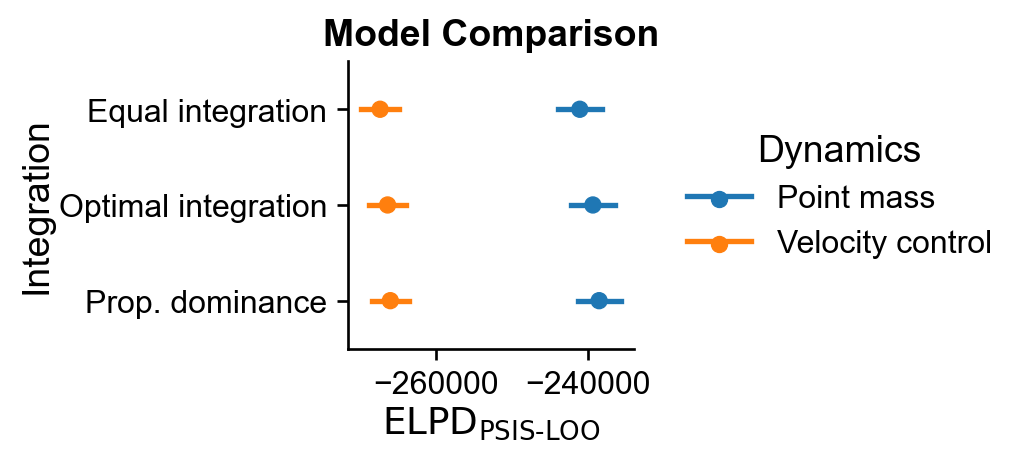

In [79]:

# compute the lower and upper bounds of ELPD 95 % CIs (+- 1.96 * se) of the ELPD-LOO sum for each model
group_stats["elpd_low"] = group_stats["elpd_sum"] - 1.96 * group_stats["se_sum"]
group_stats["elpd_high"] = group_stats["elpd_sum"] + 1.96 * group_stats["se_sum"]

g = (so.Plot(group_stats, y="integration", x="elpd_sum", color="dynamics")
      .add(so.Dot())
      .add(so.Range(), xmin="elpd_low", xmax="elpd_high")
      # .add(so.Dot(pointsize=2), so.Jitter())
      .layout(size=(3.5,2.5))
      .scale(y=so.Nominal(),
             x=so.Continuous().tick(upto=2))
      .label(x=r"$\text{ELPD}_{\text{PSIS-LOO}}$", y="Integration", color="Dynamics", title="Model Comparison")
)
g.save("../figures/multisensory_model_comparison.svg")

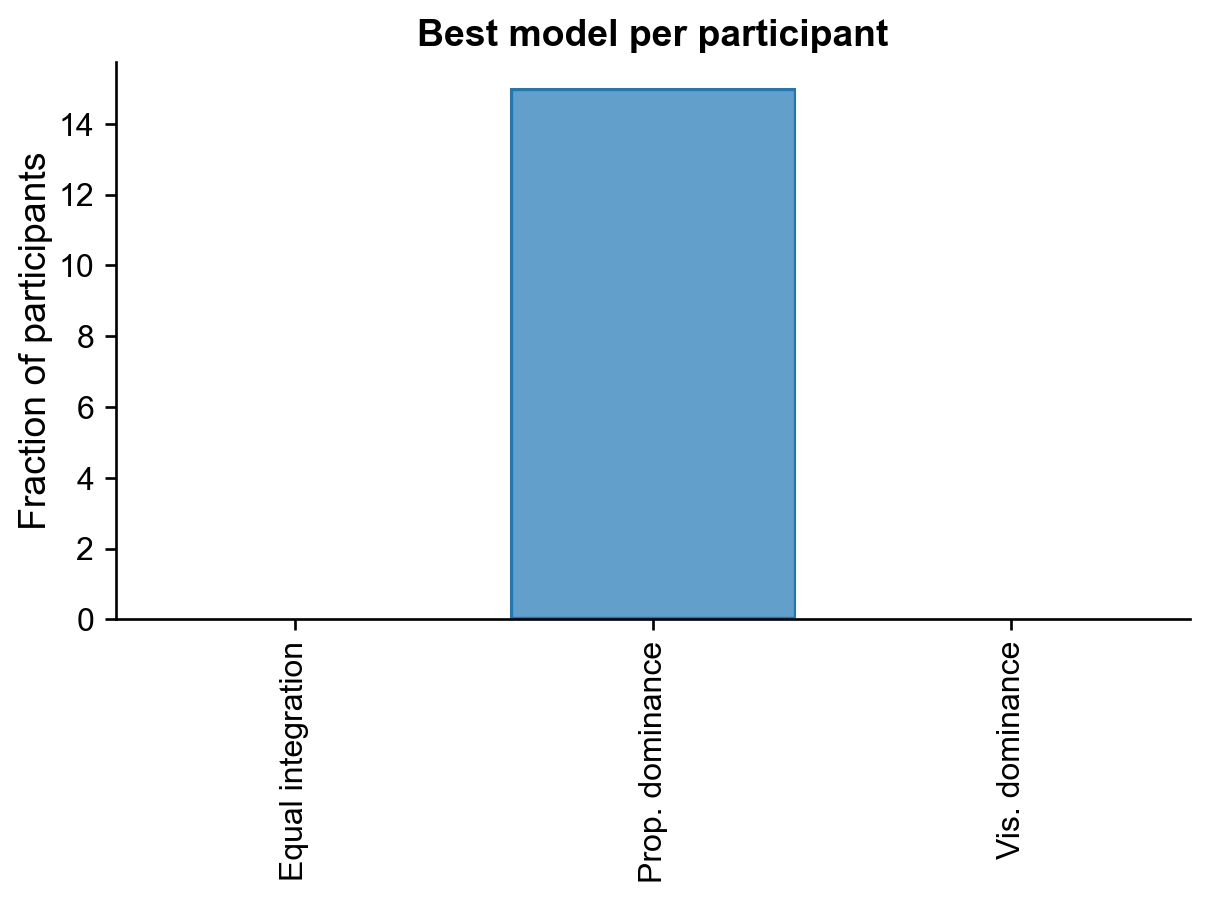

In [80]:
best_per_participant = (
    loo_df.loc[loo_df.groupby("participant")["elpd"].idxmax(), ["integration", "dynamics", "participant"]]
)

win_counts = (
    best_per_participant["integration"].value_counts()
    .reindex(model_order, fill_value=0)
    .reset_index()
)
win_counts.columns = ["integration", "wins"]
win_counts["n_participants"] = win_counts["wins"] 

g = (
    so.Plot(win_counts, x="integration", y="n_participants")
    .add(so.Bar())
    .scale(x=so.Nominal(order=model_order))
    .label(x="", y="Fraction of participants", title="Best model per participant")
).plot()
for axis in g._figure.axes:
    axis.xaxis.set_tick_params(rotation=90)
g

## Parameter estimates (uncertainty, cost, variability) 

In [81]:
df = pd.read_csv("../results/aggregated/summaries_all_participants.csv", index_col = 0)



df["integration"] = df["integration"].map(integration_name)
df["dynamics"] = df["model"].map({ "BoundedActorPointMassDynamics": "Point mass", "BoundedActor": "Velocity control" })


In [82]:
param_names = {"sigma_prop": "Hand", "sigma_vis[0]": "Cursor", "sigma_vis[1]": "Cloud",
               "action_variability": "Action variability", "action_cost": "Action cost", 
               "vis_prop_diff[0]": "Cursor - hand", "vis_prop_diff[1]": "Cloud - hand"}

# get the parts of df that correspond to the best model for each participant
best_model_params = df.merge(best_per_participant, on=["participant", "integration", "dynamics"])
best_model_params["parameter"] = best_model_params["parameter"].map(lambda x: param_names.get(x, x))
df["parameter"] = df["parameter"].map(lambda x: param_names.get(x, x))


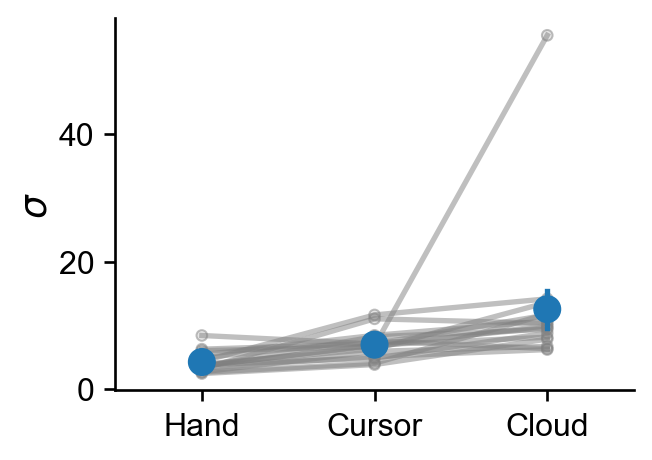

In [83]:
g = (
    so.Plot(
        best_model_params[
           (best_model_params["parameter"].isin(
                    ["Hand", "Cursor", "Cloud"]
                )
            )
        ],
        x="parameter",
        y="mean",
        # color="participant",
    )

    .add(so.Dots(color="gray", alpha=0.5), group="participant")
    .add(so.Line(color="gray", alpha=0.5), group="participant")
    .add(so.Dot(pointsize=10, artist_kws={"zorder": 10}), so.Agg())
    .add(so.Range(artist_kws={"zorder": 10}), so.Est(errorbar="se"))
    # .add(so.Dot(), so.Agg())
    # .add(so.Range(), so.Est(errorbar="se"))
    # .limit(y=(0, 25.0))
    .label(x="", y=r"$\sigma$")
    .layout(size=(3.5, 2.5))
    .scale(color=so.Nominal())
    # .facet(col="parameter")
    # .share(y=False)
)
g.save("../figures/multisensory_model_parameters.svg")

We tested whether proprioceptive uncertainty was lower than visual uncertainty by computing the posterior distribution of the difference between the proprioceptive and both visual uncertainty parameters. The 94% highest-density interval was fully above zero in 16 out of 16 participants for the difference between cursor and and and in 15 out of 16 participants for the difference between cloud and hand. This indicates that proprioceptive uncertainty was lower than visual uncertainty in most participants.

In [84]:
best_model_params[best_model_params["parameter"].isin(["Cursor - hand", "Cloud - hand"])].groupby(["parameter"]).apply(lambda x: (x["hdi_3%"] > 0.).sum())

/tmp/ipykernel_2624127/435023660.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_model_params[best_model_params["parameter"].isin(["Cursor - hand", "Cloud - hand"])].groupby(["parameter"]).apply(lambda x: (x["hdi_3%"] > 0.).sum())


parameter
Cloud - hand     16
Cursor - hand    15
dtype: int64

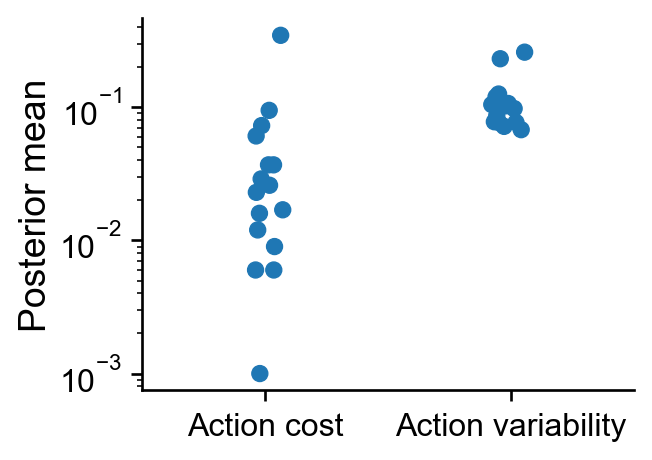

In [85]:


g = (
    so.Plot(
        best_model_params[
            (
                best_model_params["parameter"].isin(
                    ["Action cost", "Action variability"]
                )
            )
        ],
        x="parameter",
        y="mean",
        # color="model_short",
    )
    .add(so.Dot(), so.Jitter())
    # .add(so.Line(), group="participant")
    # .add(so.Dot(), so.Agg())
    # .add(so.Range(), so.Est(errorbar="se"))
    # .limit(y=(0, 1.0))
    .label(x="", y="Posterior mean")
    .scale(color=so.Nominal(), y="log")
    # .facet(col="parameter")
    .layout(size=(3.5, 2.5))
)
g.save("../figures/multisensory_model_parameters.svg")

## Posterior predictive for a representative participant

Plotting trajectories for participant 

## Load and plot simulated CCGs

We load the posterior-predictive checks for the cross-correlograms.

In [41]:
ccgs = pd.concat([pd.read_csv(f"../results/ppc/multisensory-simulations-ppc-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

ccgs["Condition"] = ccgs["condition"].map({"vis": "Vision", "prop": "Proprioception", "multi": "Multisensory"})
ccgs["Visual target"] = ccgs["vis_noise"].map({1: "Cursor", 2: "Cloud"})
ccgs["model"] = ccgs["model"].map({"data": "Data", "optimal": "Optimal integration", "no_integration": "No integration", "equal_integration": "Equal integration"})

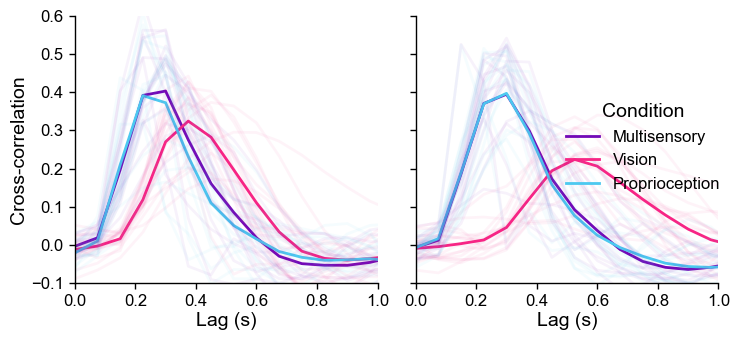

In [42]:
palette = {'Vision': "#F72585", 'Proprioception':  "#4CC9F0", 'Multisensory': "#7209B7"}
g = (so.Plot(ccgs[ccgs["model"] == "Data"], x="lag", y="correlation", color="Condition")
    .add(so.Line(), so.Agg())
    .add(so.Line(alpha=0.05), so.Agg(), group="participant")
    # .add(so.Band(), so.Est())
    .facet(col="vis_noise", 
    # row="model", order={"row": ["data", "optimal", "no_integration", "equal_integration"]}
           )
    .label(x="Lag (s)", y="Cross-correlation", title="")
    .limit(x=(-0.0, 1.0), y=(-0.1, 0.6))
    # .scale(color=so.Nominal({"vis": sns.color_palette("colorblind")[3], "prop": sns.color_palette("colorblind")[0], "multi": sns.color_palette("colorblind")[4]}))
    .scale(color=so.Nominal(palette))
    .layout(size=(7.5, 3.5))
)
g.show()

## CCG parameters (peak)

In [43]:
ccg_params = ccgs.groupby(["participant", "model", "Condition", "Visual target"]).apply(
    lambda g: pd.Series({
        'peak': g['correlation'].max(),
        'lag': g.loc[g['correlation'].idxmax(), 'lag']
    }),
    include_groups=False
).reset_index()

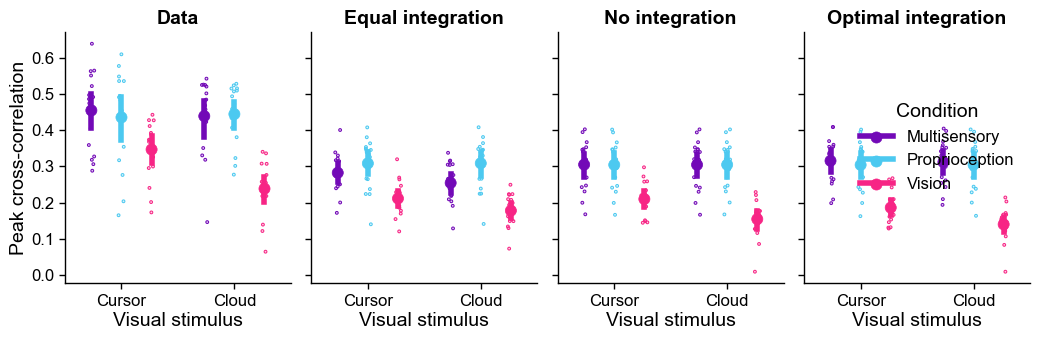

In [44]:
g = (so.Plot(ccg_params, x="Visual target", y="peak", color="Condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="model")
    .scale(x=so.Nominal(order=["Cursor", "Cloud"]), color=so.Nominal(palette))
    .label(x="Visual stimulus", y="Peak cross-correlation")
    .layout(size=(10.5, 3.5))
    # .share(y=False)
)

g.show()

## Compare data and simulations in calibration phase


First, we load the model simulations for all participants

In [19]:
df_sim = pd.concat([pd.read_csv(f"../results/calibration/multisensory-simulations-calibration-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]


In [20]:
df = df[df["time_within_trial"] > 3.0]

# replace 'value' with your measurement column name
pre_means = (
    df[df['phase'] == 'pre_cal']
    .groupby(['participant', 'type', 'vis_noise'])['tracking_error']
    .mean()
    .reset_index(name='pre_mean')
)

df = df.merge(pre_means, on=['participant', 'type', 'vis_noise'], how='left')
df['tracking_error'] = df['tracking_error'] - df['pre_mean']
# optional: handle groups with no pre_cal by filling
# df['tracking_error_centered'] = df['value'] - df['pre_mean'].fillna(0)

# add data to simulation dataframe
df["model"] = "data"

In [21]:
df_sim = pd.concat([df, df_sim]).reset_index(drop=True)

In [22]:
df_sim["abs_cursor_offset"] = df_sim["cursor_offset"].abs()

df_sim["model"] = df_sim["model"].map({"data": "Data", "optimal": "Optimal integration", "no_integration": "No integration", "equal_integration": "Equal integration"})
df_sim["Visual target"] = df_sim["vis_noise"].map({1: "Cursor", 2: "Cloud"})
df_sim["Visual uncertainty"] = df_sim["vis_noise"].map({1: "Low", 2: "High"})

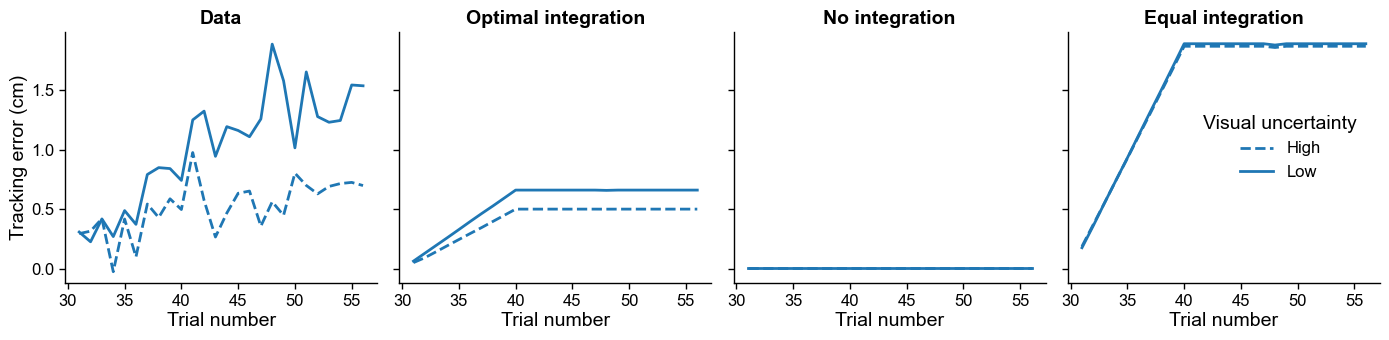

In [25]:
#  "Optimal integration", "No integration"

mean_df = (
    df_sim[
        (df_sim["phase"].isin(["calibration"]))
    ]
    .groupby(["trial_number", "model", "Visual uncertainty", "participant"])[
        ["tracking_error", "abs_cursor_offset"]
    ]
    .median()
    .reset_index()
)


g = (
    so.Plot(
        # df_sim[
        #     (df_sim["phase"].isin(["calibration"]))
        #     & (df_sim["model"].isin(["Data", "Optimal integration", "No integration"]))
        #     # & (df_sim["participant"] == 182095555)
        # ],
        mean_df,
        x="trial_number",
        y="tracking_error",
        linestyle="Visual uncertainty",
    )
    .add(so.Line(), so.Agg("mean"))
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset", color=None)
    # .add(so.Band(), so.Est(errorbar="ci"))
    # .add(so.Line(alpha=0.1), so.Agg(), group="participant")
    .scale(linestyle=so.Nominal({"Low": "-", "High": "--"}))
    .facet(col="model", order=["Data", "Optimal integration", "No integration", "Equal integration"])
    .layout(size=(14, 3.5))
    .label(x="Trial number", y="Tracking error (cm)")
)
g.show()